# DoWhy Tutorial 10: GCM Structural Causal Models

The previous notebooks focused on the classic DoWhy workflow: define a graph, identify an estimand, estimate an effect, and refute the result. This notebook introduces a different but related part of DoWhy: **graphical causal models**, usually called **GCMs**.

A GCM does not only say which variables cause which other variables. It also attaches a **causal mechanism** to each node. For example, a root node might be modeled by an empirical distribution, while a non-root node might be modeled as an additive-noise function of its parents.

That extra structure lets us ask richer questions:

- Can the fitted mechanisms regenerate data that look like the observed data?
- Which parents are most influential for a target node's mechanism?
- Does a graph miss important parent relationships?
- Are local causal mechanisms well fit before we use the model for simulations?

This notebook stays focused on mechanism assignment, fitting, sampling, and evaluation. The next notebook will go deeper into interventions and counterfactuals with GCMs.

## Learning Goals

By the end of this notebook, you should be able to:

- Explain the difference between a causal graph and a graphical causal model.
- Build a `StructuralCausalModel` from a NetworkX graph.
- Use DoWhy GCM's automatic mechanism assignment.
- Fit node-level causal mechanisms to data.
- Draw synthetic joint samples from a fitted GCM.
- Compare observed and generated distributions.
- Evaluate local mechanism quality with DoWhy's GCM evaluation API.
- Estimate direct parent influence for a target node.
- See how a misspecified graph degrades mechanism fit.

## Why GCMs Are Different

A standard causal graph stores structural assumptions such as `X -> Y`. A GCM goes one level deeper and says how each node is generated from its parents and noise.

For example, a graph might say:

\[
watch\_time \rightarrow retention\_score
\]

A GCM adds a mechanism:

\[
retention\_score = f(watch\_time, user\_intent, content\_quality) + N
\]

The mechanism can be linear, nonlinear, categorical, probabilistic, manually specified, or automatically selected. Once those mechanisms are fitted, the model can generate synthetic samples and support downstream what-if analysis.

## Setup

The setup cell imports the libraries, suppresses known non-actionable warnings, creates output folders, and disables DoWhy progress bars so notebook execution stays clean. The `MPLCONFIGDIR` setting avoids Matplotlib cache warnings in shared or sandboxed environments.

In [1]:
from pathlib import Path
import os
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-ranking-sys")

warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")
warnings.filterwarnings("ignore", message=".*setParseAction.*deprecated.*")
warnings.filterwarnings("ignore", message=".*copy keyword is deprecated.*")
warnings.filterwarnings("ignore", message=".*disp.*iprint.*L-BFGS-B.*")
warnings.filterwarnings("ignore", message=".*variables are assumed unobserved.*")
warnings.filterwarnings("ignore", module="dowhy.causal_estimators.regression_estimator")
warnings.filterwarnings("ignore", module="sklearn.linear_model._logistic")
warnings.filterwarnings("ignore", module="seaborn.categorical")
warnings.filterwarnings("ignore", module="pydot.dot_parser")

import dowhy
import dowhy.gcm as gcm
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from dowhy.gcm import auto
from dowhy.gcm.model_evaluation import EvaluateCausalModelConfig
from IPython.display import display
from matplotlib.patches import FancyArrowPatch

# Keep generated notebooks readable and deterministic enough for tutorial output.
gcm.config.show_progress_bars = False
np.random.seed(1010)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 150)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="whitegrid", context="notebook")

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "notebooks" / "tutorials" / "dowhy").exists():
        PROJECT_ROOT = candidate
        break
else:
    PROJECT_ROOT = Path.cwd()

NOTEBOOK_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "dowhy"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

RNG = np.random.default_rng(1010)

print(f"DoWhy version: {dowhy.__version__}")
print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Figure output directory: {FIGURE_DIR}")
print(f"Table output directory: {TABLE_DIR}")

DoWhy version: 0.14
Notebook directory: /home/apex/Documents/ranking_sys/notebooks/tutorials/dowhy
Figure output directory: /home/apex/Documents/ranking_sys/notebooks/tutorials/dowhy/outputs/figures
Table output directory: /home/apex/Documents/ranking_sys/notebooks/tutorials/dowhy/outputs/tables


The notebook is ready once the DoWhy version and output folders print. Every saved artifact from this notebook uses a `10_` prefix.

## GCM Workflow Map

The table below gives the workflow for this notebook. The key shift is that we are no longer only estimating one treatment effect. We are fitting a full set of local mechanisms attached to a graph.

In [2]:
gcm_workflow = pd.DataFrame(
    [
        {
            "step": "Specify graph",
            "main question": "Which variables are direct parents of each node?",
            "why it matters": "The graph determines which inputs each mechanism receives.",
        },
        {
            "step": "Assign mechanisms",
            "main question": "What model should describe each root or non-root node?",
            "why it matters": "Root nodes need distributions; non-root nodes need conditional mechanisms.",
        },
        {
            "step": "Fit mechanisms",
            "main question": "Can each mechanism learn its local data-generating pattern?",
            "why it matters": "A weak local mechanism can make downstream simulations unreliable.",
        },
        {
            "step": "Draw samples",
            "main question": "Can the fitted model regenerate realistic joint data?",
            "why it matters": "Generated samples reveal whether the model captures broad distributional structure.",
        },
        {
            "step": "Evaluate model",
            "main question": "Which mechanisms fit well, and which need attention?",
            "why it matters": "Mechanism-level diagnostics guide graph and model revisions.",
        },
        {
            "step": "Inspect parent influence",
            "main question": "Which parents matter most for a target mechanism?",
            "why it matters": "Influence summaries make fitted mechanisms easier to audit.",
        },
    ]
)

gcm_workflow.to_csv(TABLE_DIR / "10_gcm_workflow_map.csv", index=False)
display(gcm_workflow)

,step,main question,why it matters
0,Specify graph,Which variables are direct parents of each node?,The graph determines which inputs each mechani...
1,Assign mechanisms,What model should describe each root or non-ro...,Root nodes need distributions; non-root nodes ...
2,Fit mechanisms,Can each mechanism learn its local data-genera...,A weak local mechanism can make downstream sim...
3,Draw samples,Can the fitted model regenerate realistic join...,Generated samples reveal whether the model cap...
4,Evaluate model,"Which mechanisms fit well, and which need atte...",Mechanism-level diagnostics guide graph and mo...
5,Inspect parent influence,Which parents matter most for a target mechanism?,Influence summaries make fitted mechanisms eas...


The workflow is modular: each node has its own mechanism, but the graph connects those mechanisms into a joint data-generating system.

## Simulate A Recommendation-Style Causal System

We will use a continuous teaching dataset with six variables. Three root variables describe upstream context: `user_intent`, `content_quality`, and `content_novelty`. These roots influence `recommendation_exposure`, which influences `watch_time`, which then influences `retention_score`.

The final outcome, `retention_score`, also has direct parents `user_intent` and `content_quality`. This gives the GCM a realistic mix of direct and mediated relationships.

In [3]:
def make_gcm_teaching_data(n=2_400, seed=1010):
    local_rng = np.random.default_rng(seed)

    user_intent = local_rng.normal(loc=0.0, scale=1.0, size=n)
    content_quality = local_rng.normal(loc=0.0, scale=1.0, size=n)
    content_novelty = local_rng.normal(loc=0.0, scale=1.0, size=n)

    recommendation_exposure = (
        0.80 * user_intent
        + 0.45 * content_quality
        + 0.25 * content_novelty
        + local_rng.normal(scale=0.80, size=n)
    )
    watch_time = (
        1.10 * recommendation_exposure
        + 0.55 * user_intent
        + 0.50 * content_quality
        + local_rng.normal(scale=0.90, size=n)
    )
    retention_score = (
        1.35 * watch_time
        + 0.35 * user_intent
        + 0.25 * content_quality
        + local_rng.normal(scale=1.00, size=n)
    )

    df = pd.DataFrame(
        {
            "user_intent": user_intent,
            "content_quality": content_quality,
            "content_novelty": content_novelty,
            "recommendation_exposure": recommendation_exposure,
            "watch_time": watch_time,
            "retention_score": retention_score,
        }
    )
    true_watch_to_retention = 1.35
    true_exposure_to_watch = 1.10
    true_exposure_to_retention_total_via_watch = true_exposure_to_watch * true_watch_to_retention
    return df, true_exposure_to_retention_total_via_watch

gcm_df, true_total_exposure_effect = make_gcm_teaching_data()

print(f"Rows: {len(gcm_df):,}")
print(f"True exposure-to-retention effect through watch time: {true_total_exposure_effect:.3f}")
display(gcm_df.head())

Rows: 2,400
True exposure-to-retention effect through watch time: 1.485


,user_intent,content_quality,content_novelty,recommendation_exposure,watch_time,retention_score
0,-1.6987,0.1318,-1.6164,0.0231,-1.2712,-2.0215
1,0.5380,0.8367,-0.5806,1.3200,3.1298,5.6626
2,-0.2256,-0.8977,-0.6099,0.3164,1.2791,1.6556
3,-1.0902,-0.5744,-0.0702,-0.5915,-2.8416,-3.4589
4,0.5539,-0.0609,-0.1177,0.2408,-0.0293,-0.8117


The true mediated effect is printed for context, but this notebook is not centered on one effect estimate. The main goal is to fit and evaluate the full generative causal model.

## Data Field Guide

The table below documents the variable roles. GCMs make this especially important because each role implies a different type of mechanism: root distribution or conditional mechanism.

In [4]:
field_guide = pd.DataFrame(
    [
        {
            "column": "user_intent",
            "role": "root node",
            "description": "Upstream user-level signal that affects exposure, watch time, and retention.",
        },
        {
            "column": "content_quality",
            "role": "root node",
            "description": "Upstream content-level signal that affects exposure, watch time, and retention.",
        },
        {
            "column": "content_novelty",
            "role": "root node",
            "description": "Upstream content novelty signal that affects recommendation exposure.",
        },
        {
            "column": "recommendation_exposure",
            "role": "non-root node",
            "description": "Exposure intensity generated from the upstream root variables.",
        },
        {
            "column": "watch_time",
            "role": "non-root mediator",
            "description": "Engagement variable generated from exposure, intent, and quality.",
        },
        {
            "column": "retention_score",
            "role": "non-root outcome",
            "description": "Final outcome generated from watch time, intent, and quality.",
        },
    ]
)

field_guide.to_csv(TABLE_DIR / "10_field_guide.csv", index=False)
display(field_guide)

,column,role,description
0,user_intent,root node,Upstream user-level signal that affects exposu...
1,content_quality,root node,Upstream content-level signal that affects exp...
2,content_novelty,root node,Upstream content novelty signal that affects r...
3,recommendation_exposure,non-root node,Exposure intensity generated from the upstream...
4,watch_time,non-root mediator,"Engagement variable generated from exposure, i..."
5,retention_score,non-root outcome,"Final outcome generated from watch time, inten..."


The root nodes will be modeled as marginal distributions. The non-root nodes will be modeled as functions of their parents plus noise.

## Basic Data Checks

Before building a GCM, check shape, missingness, and distribution summaries. Missing values and unexpected data types can make automatic mechanism assignment fail or choose the wrong kind of mechanism.

In [5]:
basic_quality = pd.DataFrame(
    {
        "rows": [len(gcm_df)],
        "columns": [gcm_df.shape[1]],
        "missing_cells": [int(gcm_df.isna().sum().sum())],
        "mean_retention_score": [gcm_df["retention_score"].mean()],
        "std_retention_score": [gcm_df["retention_score"].std()],
    }
)

numeric_summary = gcm_df.describe().T

basic_quality.to_csv(TABLE_DIR / "10_basic_quality.csv", index=False)
numeric_summary.to_csv(TABLE_DIR / "10_numeric_summary.csv")

display(basic_quality)
display(numeric_summary)

,rows,columns,missing_cells,mean_retention_score,std_retention_score
0,2400,6,0,0.0548,3.3959


,count,mean,std,min,25%,50%,75%,max
user_intent,2400.0000,0.0276,1.0014,-3.0667,-0.6448,0.0276,0.6951,3.5708
content_quality,2400.0000,-0.0062,0.9832,-3.3342,-0.6738,0.0099,0.6452,3.4192
content_novelty,2400.0000,-0.0340,0.9895,-4.0167,-0.6972,-0.0267,0.5958,3.3365
recommendation_exposure,2400.0000,0.0294,1.2420,-4.6289,-0.8015,0.0232,0.8743,3.9199
watch_time,2400.0000,0.0289,2.1528,-7.6553,-1.3913,0.0395,1.5293,7.6264
retention_score,2400.0000,0.0548,3.3959,-12.8045,-2.1505,0.0581,2.3506,11.6465


The data are complete and continuous. That makes this a good setting for additive-noise mechanisms selected by DoWhy's auto-assignment helper.

## Define The Causal Graph

A GCM starts with a graph. Here the graph is a NetworkX directed acyclic graph. Each edge means the child node's mechanism can use the parent node as an input.

In [6]:
GCM_EDGES = [
    ("user_intent", "recommendation_exposure"),
    ("content_quality", "recommendation_exposure"),
    ("content_novelty", "recommendation_exposure"),
    ("recommendation_exposure", "watch_time"),
    ("user_intent", "watch_time"),
    ("content_quality", "watch_time"),
    ("watch_time", "retention_score"),
    ("user_intent", "retention_score"),
    ("content_quality", "retention_score"),
]

causal_graph = nx.DiGraph(GCM_EDGES)

edge_table = pd.DataFrame(GCM_EDGES, columns=["parent", "child"])
edge_table.to_csv(TABLE_DIR / "10_causal_graph_edges.csv", index=False)
display(edge_table)
print(f"Is the graph acyclic? {nx.is_directed_acyclic_graph(causal_graph)}")

,parent,child
0,user_intent,recommendation_exposure
1,content_quality,recommendation_exposure
2,content_novelty,recommendation_exposure
3,recommendation_exposure,watch_time
4,user_intent,watch_time
5,content_quality,watch_time
6,watch_time,retention_score
7,user_intent,retention_score
8,content_quality,retention_score


Is the graph acyclic? True


The acyclicity check should be true. GCM sampling requires a topological order so parent samples can be generated before child samples.

## Draw The Causal Graph

This helper draws the graph with visible arrows and spaced node boxes. Clear graph visuals are useful because a GCM is only as credible as the structural assumptions it encodes.

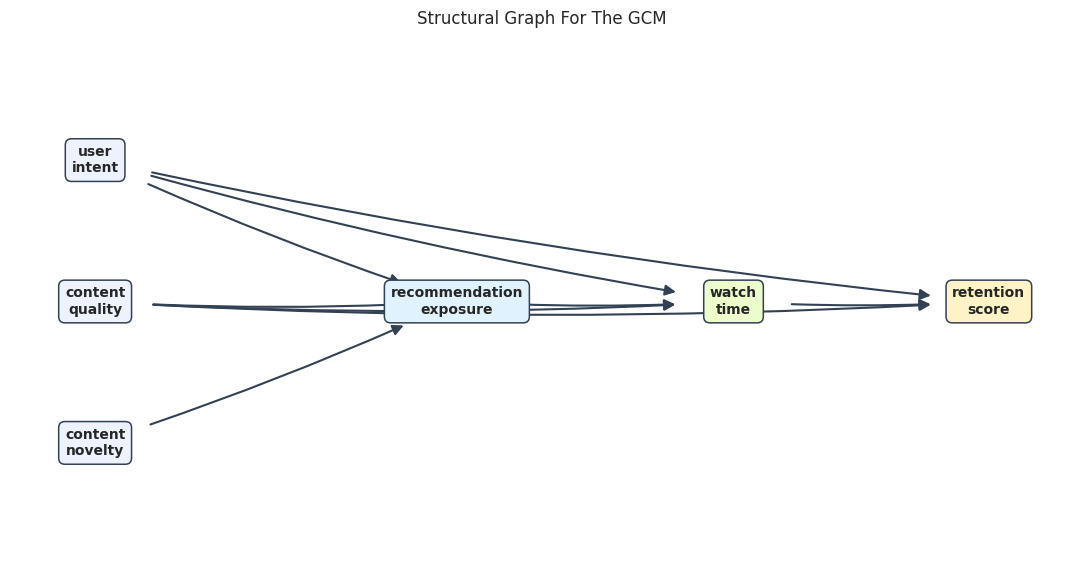

In [7]:
GCM_POSITIONS = {
    "user_intent": (0.08, 0.78),
    "content_quality": (0.08, 0.50),
    "content_novelty": (0.08, 0.22),
    "recommendation_exposure": (0.42, 0.50),
    "watch_time": (0.68, 0.50),
    "retention_score": (0.92, 0.50),
}

NODE_COLORS = {
    "user_intent": "#eef2ff",
    "content_quality": "#eef2ff",
    "content_novelty": "#eef2ff",
    "recommendation_exposure": "#e0f2fe",
    "watch_time": "#ecfccb",
    "retention_score": "#fef3c7",
}


def draw_directed_graph(edges, positions, title, path, node_colors=None):
    node_colors = node_colors or {}
    nodes = list(dict.fromkeys([node for edge in edges for node in edge]))

    fig, ax = plt.subplots(figsize=(11, 5.8))
    ax.set_axis_off()

    for left, right in edges:
        arrow = FancyArrowPatch(
            positions[left],
            positions[right],
            arrowstyle="-|>",
            mutation_scale=16,
            linewidth=1.5,
            color="#334155",
            shrinkA=42,
            shrinkB=42,
            connectionstyle="arc3,rad=0.03",
        )
        ax.add_patch(arrow)

    for node in nodes:
        x, y = positions[node]
        ax.text(
            x,
            y,
            node.replace("_", "\n"),
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.45",
                facecolor=node_colors.get(node, "#e0f2fe"),
                edgecolor="#334155",
                linewidth=1.1,
            ),
        )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(title, pad=18)
    plt.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()

draw_directed_graph(
    GCM_EDGES,
    GCM_POSITIONS,
    "Structural Graph For The GCM",
    FIGURE_DIR / "10_structural_graph.png",
    node_colors=NODE_COLORS,
)

The graph separates upstream root causes, an exposure node, an engagement mediator, and a downstream outcome. Every non-root node will receive a fitted causal mechanism.

## Build A Structural Causal Model Object

Now we wrap the NetworkX graph in DoWhy's `StructuralCausalModel`. At this moment the graph exists, but no node has a fitted mechanism yet.

In [8]:
structural_model = gcm.StructuralCausalModel(causal_graph)

model_structure_table = pd.DataFrame(
    [
        {
            "node": node,
            "parents": ", ".join(causal_graph.predecessors(node)) or "none",
            "children": ", ".join(causal_graph.successors(node)) or "none",
            "is_root": causal_graph.in_degree(node) == 0,
        }
        for node in causal_graph.nodes
    ]
)

model_structure_table.to_csv(TABLE_DIR / "10_model_structure_table.csv", index=False)
display(model_structure_table)

,node,parents,children,is_root
0,user_intent,none,"recommendation_exposure, watch_time, retention...",True
1,recommendation_exposure,"user_intent, content_quality, content_novelty",watch_time,False
2,content_quality,none,"recommendation_exposure, watch_time, retention...",True
3,content_novelty,none,recommendation_exposure,True
4,watch_time,"recommendation_exposure, user_intent, content_...",retention_score,False
5,retention_score,"watch_time, user_intent, content_quality",none,False


The root nodes have no parents and need marginal distributions. The other nodes need conditional mechanisms based on their listed parents.

## Auto-Assign Causal Mechanisms

DoWhy can automatically assign mechanisms based on the graph and data. For root nodes, it typically assigns an empirical distribution. For continuous non-root nodes, it can assign additive-noise models with a selected prediction model.

We use `AssignmentQuality.GOOD` because it is fast enough for tutorial notebooks while still evaluating a useful small set of model classes.

In [9]:
assignment_summary = auto.assign_causal_mechanisms(
    structural_model,
    gcm_df,
    quality=auto.AssignmentQuality.GOOD,
    override_models=True,
)

assignment_text_path = TABLE_DIR / "10_auto_assignment_summary.txt"
assignment_text_path.write_text(str(assignment_summary))

# Show the first part of the text summary without overwhelming the notebook.
print("\n".join(str(assignment_summary).splitlines()[:28]))

When using this auto assignment function, the given data is used to automatically assign a causal mechanism to each node. Note that causal mechanisms can also be customized and assigned manually.
The following types of causal mechanisms are considered for the automatic selection:

If root node:
An empirical distribution, i.e., the distribution is represented by randomly sampling from the provided data. This provides a flexible and non-parametric way to model the marginal distribution and is valid for all types of data modalities.

If non-root node and the data is continuous:
Additive Noise Models (ANM) of the form X_i = f(PA_i) + N_i, where PA_i are the parents of X_i and the unobserved noise N_i is assumed to be independent of PA_i.To select the best model for f, different regression models are evaluated and the model with the smallest mean squared error is selected.Note that minimizing the mean squared error here is equivalent to selecting the best choice of an ANM.

If non-root node

The summary explains the mechanism families considered during assignment. The next cell turns the assigned mechanisms into a compact table.

## Inspect Assigned Mechanisms

This table shows the mechanism type assigned to each node. It is the GCM equivalent of checking your estimator configuration before fitting.

In [10]:
def mechanism_name(model, node):
    mechanism = model.causal_mechanism(node)
    return type(mechanism).__name__, str(mechanism)

mechanism_rows = []
for node in structural_model.graph.nodes:
    mechanism_type, mechanism_description = mechanism_name(structural_model, node)
    mechanism_rows.append(
        {
            "node": node,
            "parents": ", ".join(structural_model.graph.predecessors(node)) or "none",
            "mechanism_type": mechanism_type,
            "mechanism_description": mechanism_description,
        }
    )

assigned_mechanisms = pd.DataFrame(mechanism_rows)
assigned_mechanisms.to_csv(TABLE_DIR / "10_assigned_mechanisms.csv", index=False)
display(assigned_mechanisms)

,node,parents,mechanism_type,mechanism_description
0,user_intent,none,EmpiricalDistribution,Empirical Distribution
1,recommendation_exposure,"user_intent, content_quality, content_novelty",AdditiveNoiseModel,AdditiveNoiseModel using LinearRegression
2,content_quality,none,EmpiricalDistribution,Empirical Distribution
3,content_novelty,none,EmpiricalDistribution,Empirical Distribution
4,watch_time,"recommendation_exposure, user_intent, content_...",AdditiveNoiseModel,AdditiveNoiseModel using LinearRegression
5,retention_score,"watch_time, user_intent, content_quality",AdditiveNoiseModel,AdditiveNoiseModel using LinearRegression


The root nodes receive empirical distributions. The non-root nodes receive conditional mechanisms that represent relationships of the form “child equals a function of parents plus noise.”

## Fit The Mechanisms

After assignment, we fit each mechanism to the observed data. DoWhy fits each node locally: root mechanisms use the node column, and non-root mechanisms use parent columns plus the child column.

In [11]:
gcm.fit(structural_model, gcm_df)

fitted_status = pd.DataFrame(
    [
        {
            "node": node,
            "mechanism_type": type(structural_model.causal_mechanism(node)).__name__,
            "parents_used": ", ".join(structural_model.graph.predecessors(node)) or "none",
            "fitted": True,
        }
        for node in structural_model.graph.nodes
    ]
)

fitted_status.to_csv(TABLE_DIR / "10_fitted_mechanism_status.csv", index=False)
display(fitted_status)

,node,mechanism_type,parents_used,fitted
0,user_intent,EmpiricalDistribution,none,True
1,recommendation_exposure,AdditiveNoiseModel,"user_intent, content_quality, content_novelty",True
2,content_quality,EmpiricalDistribution,none,True
3,content_novelty,EmpiricalDistribution,none,True
4,watch_time,AdditiveNoiseModel,"recommendation_exposure, user_intent, content_...",True
5,retention_score,AdditiveNoiseModel,"watch_time, user_intent, content_quality",True


The fitted mechanisms now define a joint generative model. We can sample roots, propagate values through the graph, and compare the generated data with the observed data.

## Draw Synthetic Samples From The Fitted GCM

A fitted GCM can generate new joint samples. Sampling follows the graph order: draw root nodes first, then draw each child from its fitted mechanism conditional on already-drawn parents.

In [12]:
synthetic_samples = gcm.draw_samples(structural_model, num_samples=2_400)

print(f"Generated rows: {len(synthetic_samples):,}")
display(synthetic_samples.head())

Generated rows: 2,400


,user_intent,content_quality,content_novelty,recommendation_exposure,watch_time,retention_score
0,0.0418,0.5652,0.4356,1.2921,0.7702,2.3595
1,-0.1903,0.0882,0.7579,0.1603,-0.4687,-1.2741
2,1.5865,0.2247,-0.4906,0.6874,0.6954,0.7259
3,-0.8218,-0.9321,0.7321,-1.2541,-3.0251,-5.8734
4,1.3903,-0.3183,-0.8468,1.5108,2.8003,4.1785


The generated rows have the same columns as the observed data. They are not resampled rows; they are new samples generated by the fitted causal mechanisms.

## Compare Observed And Generated Summaries

If the GCM is reasonable, generated samples should have similar marginal means, standard deviations, and quantiles to the observed data. This is not enough to prove causal correctness, but it is a good first model-quality check.

In [13]:
def distribution_summary(data, label):
    summary = data.agg(["mean", "std", "median"]).T.reset_index().rename(columns={"index": "node"})
    summary["q10"] = data.quantile(0.10).values
    summary["q90"] = data.quantile(0.90).values
    summary["sample_type"] = label
    return summary

observed_summary = distribution_summary(gcm_df, "observed")
synthetic_summary = distribution_summary(synthetic_samples[gcm_df.columns], "generated")
comparison_summary = pd.concat([observed_summary, synthetic_summary], ignore_index=True)

summary_wide = comparison_summary.pivot(index="node", columns="sample_type", values=["mean", "std", "median", "q10", "q90"])
summary_wide.to_csv(TABLE_DIR / "10_observed_vs_generated_summary.csv")
display(summary_wide)

mean                std             median                q10                q90         
sample_type             generated observed generated observed generated observed generated observed generated observed
node                                                                                                                  
content_novelty           -0.0899  -0.0340    0.9799   0.9895   -0.1005  -0.0267   -1.3157  -1.3004    1.2380   1.2464
content_quality            0.0375  -0.0062    0.9614   0.9832    0.0633   0.0099   -1.1640  -1.2387    1.3215   1.2451
recommendation_exposure    0.0484   0.0294    1.2124   1.2420    0.0647   0.0232   -1.5176  -1.5737    1.5914   1.6278
retention_score            0.1594   0.0548    3.3353   3.3959    0.1987   0.0581   -4.1539  -4.3322    4.3802   4.3874
user_intent                0.0373   0.0276    0.9860   1.0014    0.0212   0.0276   -1.2293  -1.2518    1.3005   1.2991
watch_time                 0.0931   0.0289    2.1255   2.1528    0.1045   0.0395   -2.6717  -2.7374    2.8115   2.7795

The generated and observed summaries should be close. Large gaps would suggest either mechanism misspecification, graph misspecification, or both.

## Plot Observed Versus Generated Distributions

The table is precise, but distribution plots are easier to scan. Each panel overlays the observed and generated distributions for one node.

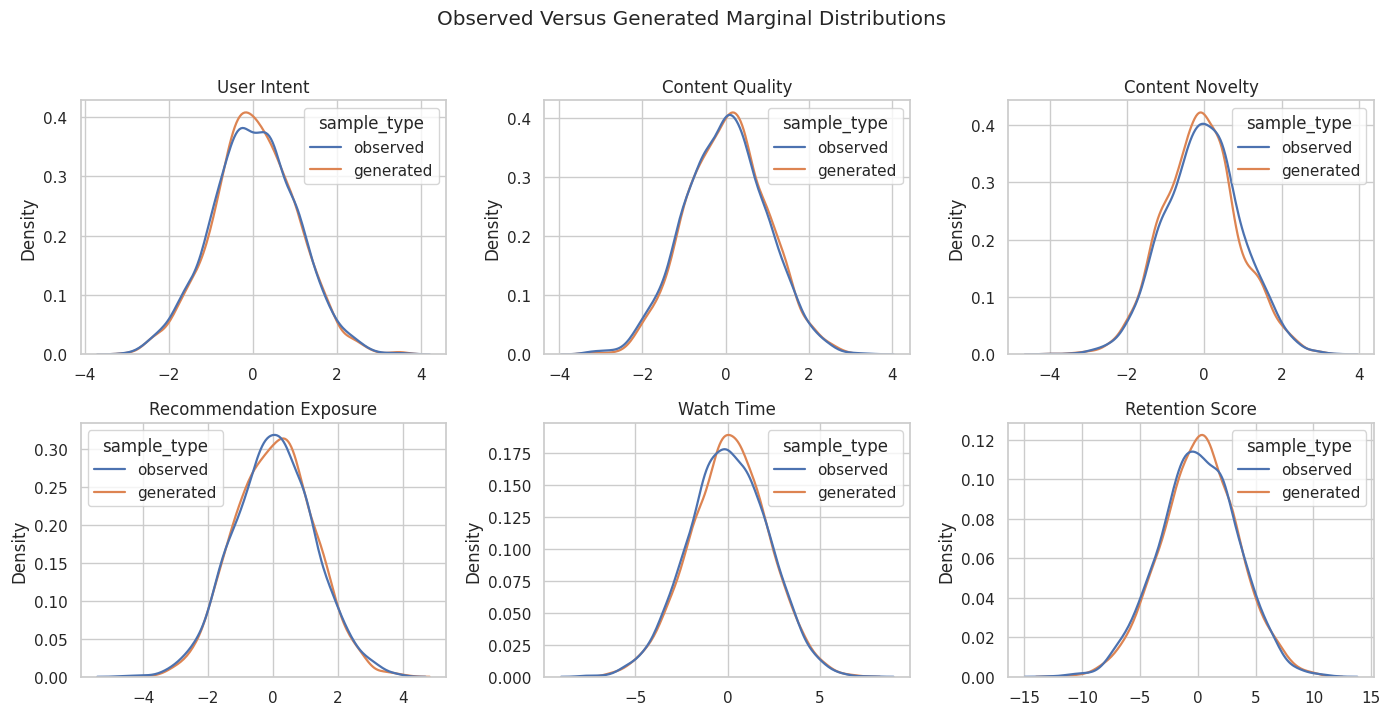

In [14]:
plot_samples = pd.concat(
    [
        gcm_df.assign(sample_type="observed"),
        synthetic_samples[gcm_df.columns].assign(sample_type="generated"),
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, node in zip(axes.flat, gcm_df.columns):
    sns.kdeplot(
        data=plot_samples,
        x=node,
        hue="sample_type",
        common_norm=False,
        fill=False,
        linewidth=1.6,
        ax=ax,
    )
    ax.set_title(node.replace("_", " ").title())
    ax.set_xlabel("")
    ax.set_ylabel("Density")

fig.suptitle("Observed Versus Generated Marginal Distributions", y=1.02)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "10_observed_vs_generated_distributions.png", dpi=160, bbox_inches="tight")
plt.show()

The generated distributions should broadly track the observed distributions. This is a generative-model check, not a causal identification guarantee.

## Evaluate The Fitted GCM

DoWhy's `evaluate_causal_model` function can evaluate mechanism performance and overall generated-versus-observed divergence. To keep runtime modest, we evaluate on a fixed sample of the data and use three folds for mechanism evaluation.

In [15]:
evaluation_data = gcm_df.sample(900, random_state=1010).reset_index(drop=True)
evaluation_config = EvaluateCausalModelConfig(mechanism_evaluation_kfolds=3, n_jobs=1)

evaluation_result = gcm.evaluate_causal_model(
    structural_model,
    evaluation_data,
    evaluate_causal_mechanisms=True,
    compare_mechanism_baselines=False,
    evaluate_invertibility_assumptions=False,
    evaluate_overall_kl_divergence=True,
    evaluate_causal_structure=False,
    config=evaluation_config,
)

print(f"Overall average KL divergence: {evaluation_result.overall_kl_divergence:.4f}")

Overall average KL divergence: 0.0110


The overall KL divergence is a compact generated-versus-observed distribution score. Smaller is better, but it should be read together with node-level mechanism performance.

## Turn Mechanism Evaluation Into A Table

The evaluation object stores metrics for each node. Root nodes have KL divergence for their marginal distributions. Non-root continuous nodes have metrics such as MSE, normalized MSE, R2, and CRPS.

In [16]:
mechanism_performance_rows = []
for node, performance in evaluation_result.mechanism_performances.items():
    mechanism_performance_rows.append(
        {
            "node": node,
            "is_root": performance.is_root,
            "kl_divergence": performance.kl_divergence,
            "mse": performance.mse,
            "nmse": performance.nmse,
            "r2": performance.r2,
            "crps": performance.crps,
        }
    )

mechanism_performance = pd.DataFrame(mechanism_performance_rows)
mechanism_performance.to_csv(TABLE_DIR / "10_mechanism_performance.csv", index=False)
display(mechanism_performance)

,node,is_root,kl_divergence,mse,nmse,r2,crps
0,user_intent,True,0.0726,NaN,NaN,NaN,NaN
1,content_quality,True,0.0608,NaN,NaN,NaN,NaN
2,content_novelty,True,0.1664,NaN,NaN,NaN,NaN
3,recommendation_exposure,False,NaN,0.6589,0.6651,0.5576,0.3836
4,watch_time,False,NaN,0.7345,0.3967,0.8426,0.2264
5,retention_score,False,NaN,0.9525,0.2872,0.9174,0.1635


The non-root mechanisms should have strong R2 values because the simulator uses clear parent relationships. If a child mechanism performs poorly, inspect its parent set and model family before trusting simulations from that node downstream.

## Plot Non-Root Mechanism R2

The R2 plot focuses on conditional mechanisms. A root node has no parent mechanism to score with R2, so roots are excluded from this chart.

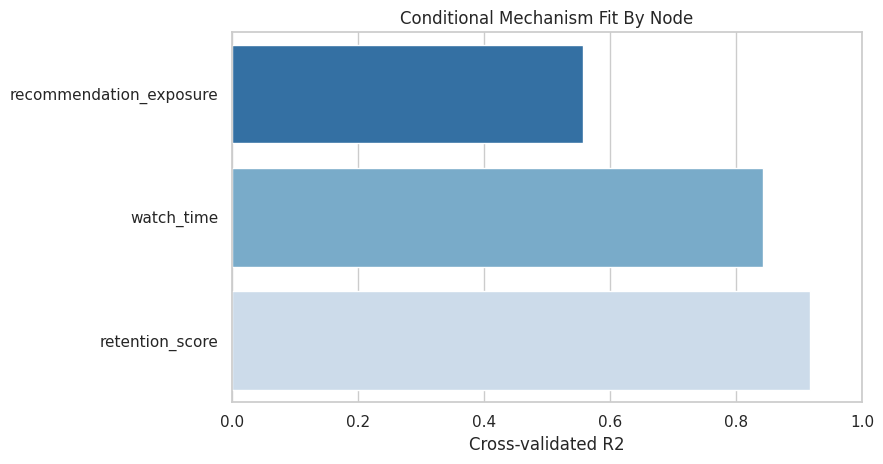

In [17]:
non_root_performance = mechanism_performance.loc[~mechanism_performance["is_root"]].copy()

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.barplot(
    data=non_root_performance,
    x="r2",
    y="node",
    hue="node",
    dodge=False,
    legend=False,
    palette="Blues_r",
    ax=ax,
)
ax.set_xlim(0, 1)
ax.set_title("Conditional Mechanism Fit By Node")
ax.set_xlabel("Cross-validated R2")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "10_mechanism_r2_by_node.png", dpi=160, bbox_inches="tight")
plt.show()

High R2 values indicate that the parents explain much of each child node's conditional expectation. This supports the graph and mechanism choices in this controlled setting.

## Inspect Direct Arrow Strength For Retention

The fitted GCM can estimate direct influence of each parent arrow into a target node. Here we inspect incoming arrows to `retention_score`. The largest direct influence should come from `watch_time`, because the simulator gives it the strongest direct coefficient.

In [18]:
retention_parents = list(structural_model.graph.predecessors("retention_score"))
retention_parent_samples = gcm_df[retention_parents]

np.random.seed(1011)
retention_arrow_strength = gcm.arrow_strength(
    structural_model,
    target_node="retention_score",
    parent_samples=retention_parent_samples,
    num_samples_conditional=300,
    max_num_runs=8,
    tolerance=0.05,
    n_jobs=1,
)

arrow_strength_table = pd.DataFrame(
    [
        {"parent": parent, "target": target, "arrow_strength": strength}
        for (parent, target), strength in retention_arrow_strength.items()
    ]
).sort_values("arrow_strength", ascending=False)

arrow_strength_table.to_csv(TABLE_DIR / "10_retention_arrow_strength.csv", index=False)
display(arrow_strength_table)

,parent,target,arrow_strength
2,watch_time,retention_score,8.2261
1,user_intent,retention_score,0.1190
0,content_quality,retention_score,0.0267


The direct arrow from `watch_time` to `retention_score` should dominate. This aligns with the simulator and helps audit whether the fitted mechanism is using parents in a sensible way.

## Parent Relevance For The Retention Mechanism

Parent relevance uses a Shapley-style idea to quantify how much each parent contributes to the target mechanism's output distribution. It also reports a noise contribution, because GCM mechanisms include unobserved noise.

In [19]:
np.random.seed(1012)
parent_relevance_values, noise_relevance_values = gcm.parent_relevance(
    structural_model,
    target_node="retention_score",
    parent_samples=retention_parent_samples.sample(700, random_state=1012),
    num_samples_randomization=700,
    num_samples_baseline=120,
    max_batch_size=120,
)

parent_relevance_table = pd.DataFrame(
    [
        {"input": parent, "target": target, "relevance": relevance, "input_type": "observed parent"}
        for (parent, target), relevance in parent_relevance_values.items()
    ]
)
noise_relevance_table = pd.DataFrame(
    [
        {
            "input": f"noise_{idx}",
            "target": "retention_score",
            "relevance": value,
            "input_type": "mechanism noise",
        }
        for idx, value in enumerate(noise_relevance_values, start=1)
    ]
)
retention_relevance_table = pd.concat([parent_relevance_table, noise_relevance_table], ignore_index=True)
retention_relevance_table = retention_relevance_table.sort_values("relevance", ascending=False)

retention_relevance_table.to_csv(TABLE_DIR / "10_retention_parent_relevance.csv", index=False)
display(retention_relevance_table)

,input,target,relevance,input_type
2,watch_time,retention_score,9.1453,observed parent
1,user_intent,retention_score,0.9053,observed parent
3,noise_1,retention_score,0.8491,mechanism noise
0,content_quality,retention_score,0.4214,observed parent


The relevance table separates observed parent influence from residual noise. A large noise contribution can indicate either genuine randomness or missing parents in the graph.

## Plot Retention Parent Relevance

The bar chart makes the relevance ranking easier to read. The goal is not to assign moral importance to variables; it is to understand the fitted retention mechanism.

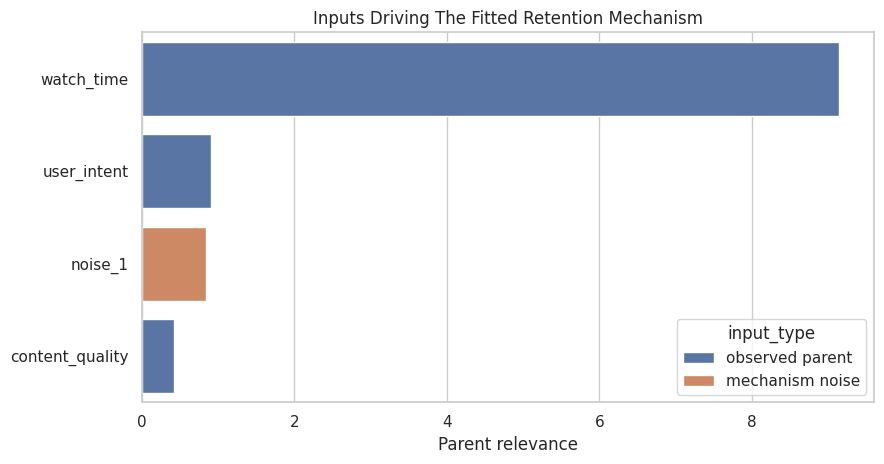

In [20]:
fig, ax = plt.subplots(figsize=(9, 4.8))
sns.barplot(
    data=retention_relevance_table,
    x="relevance",
    y="input",
    hue="input_type",
    dodge=False,
    ax=ax,
)
ax.set_title("Inputs Driving The Fitted Retention Mechanism")
ax.set_xlabel("Parent relevance")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "10_retention_parent_relevance.png", dpi=160, bbox_inches="tight")
plt.show()

The ranking should place `watch_time` near the top. This matches the structural equation used to simulate retention.

## Compare With A Misspecified Graph

A GCM can fit only the mechanisms implied by its graph. To show why this matters, we create a wrong graph that removes the edge `watch_time -> retention_score`. This forces the retention mechanism to predict retention without its most important parent.

In [21]:
MISSPECIFIED_EDGES = [edge for edge in GCM_EDGES if edge != ("watch_time", "retention_score")]
misspecified_graph = nx.DiGraph(MISSPECIFIED_EDGES)
misspecified_model = gcm.StructuralCausalModel(misspecified_graph)

missing_edge_table = pd.DataFrame(
    [
        {
            "removed_parent": "watch_time",
            "child": "retention_score",
            "reason_this_is_a_problem": "watch_time is the strongest direct driver of retention in the simulator",
        }
    ]
)
missing_edge_table.to_csv(TABLE_DIR / "10_misspecified_graph_removed_edge.csv", index=False)
display(missing_edge_table)

,removed_parent,child,reason_this_is_a_problem
0,watch_time,retention_score,watch_time is the strongest direct driver of r...


The wrong graph is intentionally missing the most important retention parent. The next cells fit and evaluate it, then compare it with the correct graph.

## Draw The Misspecified Graph

The visual makes the missing edge visible. The retention node still has parents, but it no longer receives `watch_time` as an input.

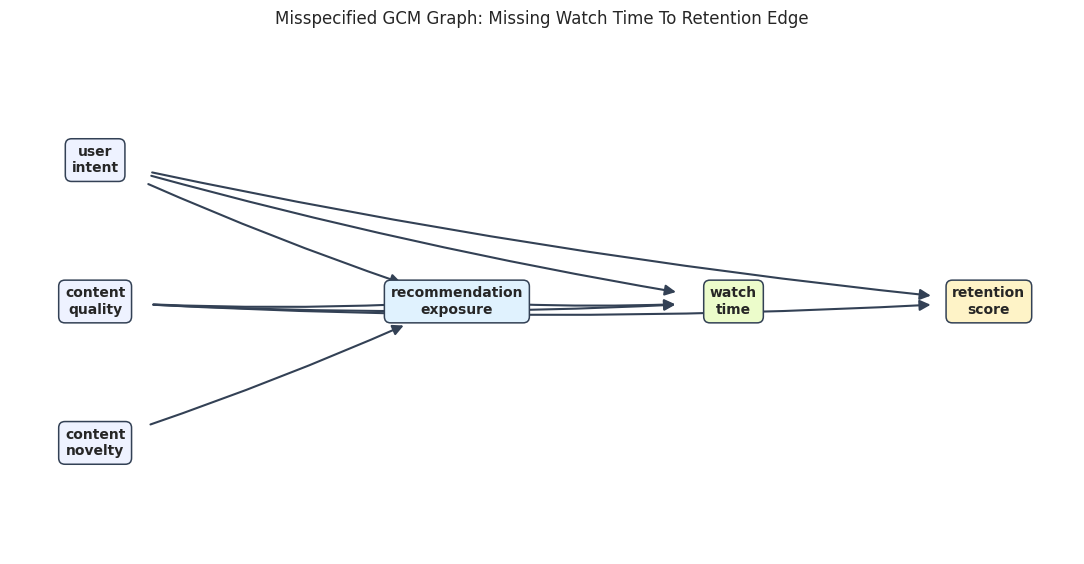

In [22]:
draw_directed_graph(
    MISSPECIFIED_EDGES,
    GCM_POSITIONS,
    "Misspecified GCM Graph: Missing Watch Time To Retention Edge",
    FIGURE_DIR / "10_misspecified_graph.png",
    node_colors=NODE_COLORS,
)

The graph is still acyclic and fit-able, but it encodes the wrong local mechanism for retention.

## Fit And Evaluate The Misspecified GCM

We use the same auto-assignment and fitting workflow on the wrong graph. If the missing parent matters, the retention mechanism should fit much worse.

In [23]:
auto.assign_causal_mechanisms(
    misspecified_model,
    gcm_df,
    quality=auto.AssignmentQuality.GOOD,
    override_models=True,
)
gcm.fit(misspecified_model, gcm_df)

misspecified_evaluation_result = gcm.evaluate_causal_model(
    misspecified_model,
    evaluation_data,
    evaluate_causal_mechanisms=True,
    compare_mechanism_baselines=False,
    evaluate_invertibility_assumptions=False,
    evaluate_overall_kl_divergence=True,
    evaluate_causal_structure=False,
    config=evaluation_config,
)

correct_retention_performance = evaluation_result.mechanism_performances["retention_score"]
wrong_retention_performance = misspecified_evaluation_result.mechanism_performances["retention_score"]

misspec_comparison = pd.DataFrame(
    [
        {
            "model": "correct graph",
            "retention_parents": ", ".join(structural_model.graph.predecessors("retention_score")),
            "retention_r2": correct_retention_performance.r2,
            "retention_nmse": correct_retention_performance.nmse,
            "retention_mse": correct_retention_performance.mse,
            "overall_kl_divergence": evaluation_result.overall_kl_divergence,
        },
        {
            "model": "misspecified graph",
            "retention_parents": ", ".join(misspecified_model.graph.predecessors("retention_score")),
            "retention_r2": wrong_retention_performance.r2,
            "retention_nmse": wrong_retention_performance.nmse,
            "retention_mse": wrong_retention_performance.mse,
            "overall_kl_divergence": misspecified_evaluation_result.overall_kl_divergence,
        },
    ]
)

misspec_comparison.to_csv(TABLE_DIR / "10_correct_vs_misspecified_gcm.csv", index=False)
display(misspec_comparison)

,model,retention_parents,retention_r2,retention_nmse,retention_mse,overall_kl_divergence
0,correct graph,"watch_time, user_intent, content_quality",0.9174,0.2872,0.9525,0.0110
1,misspecified graph,"user_intent, content_quality",0.6590,0.5835,3.9324,0.0243


The misspecified graph should have much weaker retention fit. This is the GCM version of a familiar causal lesson: if the graph omits a real parent, the downstream model quality suffers.

## Plot Correct Versus Misspecified Retention Fit

The plot compares retention R2 under the correct and misspecified graph. The missing `watch_time` parent should visibly reduce fit quality.

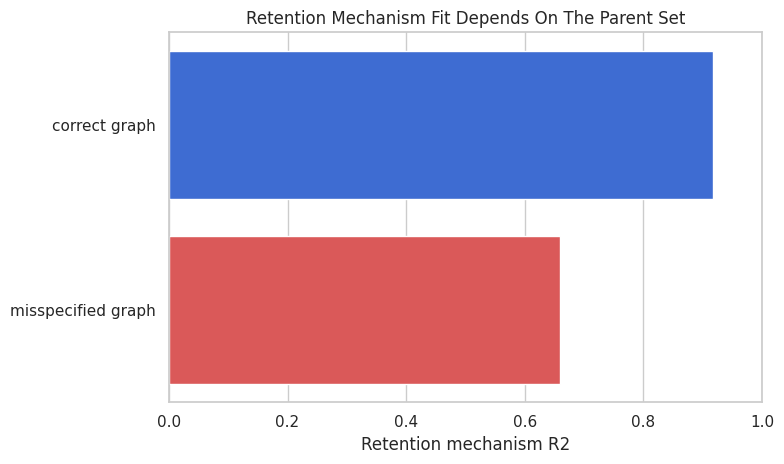

In [24]:
fig, ax = plt.subplots(figsize=(8, 4.8))
sns.barplot(
    data=misspec_comparison,
    x="retention_r2",
    y="model",
    hue="model",
    dodge=False,
    legend=False,
    palette=["#2563eb", "#ef4444"],
    ax=ax,
)
ax.set_xlim(0, 1)
ax.set_title("Retention Mechanism Fit Depends On The Parent Set")
ax.set_xlabel("Retention mechanism R2")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "10_correct_vs_misspecified_retention_fit.png", dpi=160, bbox_inches="tight")
plt.show()

This chart connects graph structure to mechanism performance. A GCM is not just a flexible predictive model; its local predictors are constrained by the causal graph.

## Final GCM Summary

The final table summarizes what the notebook established: the fitted GCM can generate realistic samples, local mechanisms can be evaluated, and graph misspecification can degrade a specific mechanism.

In [25]:
final_gcm_summary = pd.DataFrame(
    [
        {
            "topic": "mechanism assignment",
            "result": f"{len(assigned_mechanisms)} mechanisms assigned",
            "causal reading": "each graph node has a fitted distribution or conditional mechanism",
        },
        {
            "topic": "generated samples",
            "result": f"{len(synthetic_samples):,} synthetic rows drawn",
            "causal reading": "the fitted GCM defines a joint generative process",
        },
        {
            "topic": "overall generated-data fit",
            "result": f"KL divergence {evaluation_result.overall_kl_divergence:.4f}",
            "causal reading": "generated marginals are close to observed marginals in this simulation",
        },
        {
            "topic": "retention parent influence",
            "result": f"top arrow: {arrow_strength_table.iloc[0]['parent']} -> retention_score",
            "causal reading": "the fitted mechanism identifies watch time as the dominant direct retention parent",
        },
        {
            "topic": "misspecified graph",
            "result": f"retention R2 drops from {misspec_comparison.loc[0, 'retention_r2']:.3f} to {misspec_comparison.loc[1, 'retention_r2']:.3f}",
            "causal reading": "removing a real parent damages the target mechanism",
        },
    ]
)

final_gcm_summary.to_csv(TABLE_DIR / "10_final_gcm_summary.csv", index=False)
display(final_gcm_summary)

,topic,result,causal reading
0,mechanism assignment,6 mechanisms assigned,each graph node has a fitted distribution or c...
1,generated samples,"2,400 synthetic rows drawn",the fitted GCM defines a joint generative process
2,overall generated-data fit,KL divergence 0.0110,generated marginals are close to observed marg...
3,retention parent influence,top arrow: watch_time -> retention_score,the fitted mechanism identifies watch time as ...
4,misspecified graph,retention R2 drops from 0.917 to 0.659,removing a real parent damages the target mech...


The notebook shows the core GCM idea: a graph plus local mechanisms becomes a fitted data-generating system. The quality of that system depends on both the graph and the mechanism choices.

## Practical Checklist For GCM Work

Use this checklist when moving from tutorial data to real data:

- Confirm that every node is measured before or after its parents in a plausible order.
- Decide whether each variable should be a root node or a child node.
- Inspect assigned mechanism types before fitting.
- Compare generated samples with observed data before using the model for what-if analysis.
- Evaluate local mechanisms, not only the final outcome node.
- Treat poor mechanism fit as a prompt to revisit the graph, the model class, or the measurement definition.
- Remember that good generated samples do not prove the graph is causal; they only support the fitted generative story.

## Practice Prompts

Try these extensions after running the notebook:

1. Add a direct edge from `recommendation_exposure` to `retention_score`. Does the retention mechanism improve or merely become more complex?
2. Increase the noise in `watch_time`. How does the retention parent relevance change?
3. Change auto-assignment quality from `GOOD` to `BETTER`. Which mechanisms change, and does evaluation improve?
4. Replace one root distribution with a different hand-picked mechanism. How do generated samples change?
5. Write a short model card for the fitted GCM that documents graph assumptions, mechanism choices, and diagnostics.

## What Comes Next

The next tutorial uses fitted GCMs for interventions and counterfactuals. Now that we can build, fit, sample from, and evaluate a GCM, we are ready to ask what happens when we actively change a mechanism or set a variable to a new value.